# Statistical Analysis of Radioastron OJ287 Observations

## Imports

**Comment**: Below are provided imports.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

## Methods

**Comment**: Below are provided additional global methods to use in the Notebook.

In [3]:
def jd_from_datetime(dt):
    if pd.isna(dt):
        return np.nan
    year = dt.year
    month = dt.month
    day = dt.day
    hour = dt.hour + dt.minute/60.0 + dt.second/3600.0
    
    if month <= 2:
        year -= 1
        month += 12
    A = year // 100
    B = 2 - A + (A // 4)
    jd = int(365.25 * (year + 4716)) + int(30.6001 * (month + 1)) + day + B - 1524.5
    jd += hour / 24.0
    return jd

## Globals

**Comment**: Below are provided global variables.

In [4]:
# description of observational frequency bands
# P -- 316 MHz
# L -- 1668 MHz
# C -- 4828 MHz
# K -- 22236 MHz

bands = ['P', 'L', 'C', 'K']

# designation of colors for corresponding frequency bands
band_colors = {
    'P': "#DFDD83",
    'L': "#c3ff74",
    'C': "#a6f7e3",
    'K': "#86b9c9"
}

# designation of colors for corresponding correlation results
color_map = {
    0: '#3498db',   # синий     — только наземные
    1: '#2ecc71',   # зелёный   — УСПЕХ с Радиоастроном
    2: '#e74c3c',   # красный   — нет корреляции
    np.nan: '#95a5a6'  # серый — не наблюдался (x)
}

## Data Loading & Preparation

### Data Loading

**Comment**: Load table with observations.

In [5]:
df = pd.read_csv('Data_Table_18052026.txt', sep='\t')
flux = pd.read_csv('aavsodata_6a0c1ae1e02ce.txt', sep='\t')
ratan = pd.read_csv('RATAN-600_light_curves.txt', sep='\t')

**Comment**: Check head and tail of observations data table.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         94 non-null     object 
 1   Start date/time   94 non-null     object 
 2   Stop date/time    94 non-null     object 
 3   Telescopes        94 non-null     object 
 4   BL, (ED)          90 non-null     float64
 5   Bands             94 non-null     object 
 6   Tracking station  56 non-null     object 
 7   P                 94 non-null     object 
 8   L                 94 non-null     object 
 9   C                 94 non-null     object 
 10  K                 94 non-null     object 
dtypes: float64(1), object(10)
memory usage: 8.2+ KB


In [7]:
df.head()

,Obs. Code,Start date/time,Stop date/time,Telescopes,"BL, (ED)",Bands,Tracking station,P,L,C,K
0,raes03f,21.02.2012 1:30,21.02.2012 2:30,"GRT:Eb (C),Ys (C),Mc (L),Ev (L)",12.0,CL,NaN,x,0,1,x
1,raes03i,17.03.2012 15:00,17.03.2012 16:00,"GRT:Nt,Ev,Mc,Us",10.0,LC,NaN,x,2,0,x
2,raes03p,04.04.2012 18:30,04.04.2012 19:30,"GRT:Ef (C),Ys(C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
3,raes03q,05.04.2012 17:00,05.04.2012 18:00,"GRT:Ef (C),Ys (C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
4,raes03aa,27.04.2012 21:30,27.04.2012 23:30,GRT:Ar (C: 21:30-22:00; L: 22:05-22:30; P: 22:...,12.0,CLP,NaN,0,1,1,x


In [8]:
flux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7523 entries, 0 to 7522
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   JD                    7523 non-null   float64
 1   Magnitude             7523 non-null   object 
 2   Uncertainty           6339 non-null   float64
 3   HQuncertainty         0 non-null      float64
 4   Band                  7521 non-null   object 
 5   Observer Code         7523 non-null   object 
 6   Comment Code(s)       160 non-null    object 
 7   Comp Star 1           4951 non-null   object 
 8   Comp Star 2           4163 non-null   object 
 9   Charts                7409 non-null   object 
 10  Comments              1667 non-null   object 
 11  Transfomed            6691 non-null   float64
 12  Airmass               5285 non-null   float64
 13  Validation Flag       7523 non-null   object 
 14  Cmag                  3859 non-null   float64
 15  Kmag                 

In [9]:
flux.head()

,JD,Magnitude,Uncertainty,HQuncertainty,Band,Observer Code,Comment Code(s),Comp Star 1,Comp Star 2,Charts,...,Cmag,Kmag,HJD,Star Name,Observer Affiliation,Measurement Method,Grouping Method,ADS Reference,Digitizer,Credit
0,2.455980e+06,15.406,0.02,NaN,V,GCO,NaN,ENSEMBLE,000-BBQ-007,1502KG,...,NaN,13.941,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
1,2.455985e+06,15.1,0.20,NaN,V,HUR,NaN,150,NaN,JT060319,...,15.0,NaN,NaN,OJ 287,BAA-VSS,STD,NaN,NaN,NaN,NaN
2,2.455985e+06,15.08,NaN,NaN,V,PYG,NaN,S,NaN,251.02,...,14.6,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN
3,2.455985e+06,15.0,NaN,NaN,Vis.,STI,NaN,146,153,"6025en,ee",...,NaN,NaN,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
4,2.455987e+06,15.0,NaN,NaN,Vis.,PYG,B,S-4,NaN,251.02,...,NaN,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN


In [10]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           77 non-null     object
 1   21.7/22.3 GHz  77 non-null     object
 2   Unnamed: 2     77 non-null     object
 3   14.4 GHz       77 non-null     object
 4   Unnamed: 4     77 non-null     object
 5   11.2 GHz       77 non-null     object
 6   Unnamed: 6     77 non-null     object
 7   7.7/8.2 GHz    77 non-null     object
 8   Unnamed: 8     77 non-null     object
 9   4.8 GHz        77 non-null     object
 10  Unnamed: 10    77 non-null     object
 11  2.3 GHz        77 non-null     object
 12  Unnamed: 12    77 non-null     object
 13  1.1 GHz        77 non-null     object
 14  Unnamed: 14    77 non-null     object
dtypes: object(15)
memory usage: 9.2+ KB


In [11]:
ratan.head()

,Date,21.7/22.3 GHz,Unnamed: 2,14.4 GHz,Unnamed: 4,11.2 GHz,Unnamed: 6,7.7/8.2 GHz,Unnamed: 8,4.8 GHz,Unnamed: 10,2.3 GHz,Unnamed: 12,1.1 GHz,Unnamed: 14
0,15.04.2009,4.08,0.47,-,-,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,-,-
1,15.04.2011,7.82,0.87,-,-,6.85,0.24,5.64,0.11,4.5,0.09,-,-,-,-
2,15.07.2011,6.76,0.9,-,-,6.19,0.18,5.93,0.18,4.96,0.17,-,-,-,-
3,15.08.2011,4.38,0.44,-,-,5.21,0.16,5.44,0.22,4.85,0.15,-,-,-,-
4,15.09.2011,4.01,0.49,-,-,5.08,0.24,5.3,0.28,4.66,0.19,-,-,-,-


### Data Preparation

**Comment**: Prepare data and data-types.

In [12]:
for col in bands:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['BL'] = pd.to_numeric(df['BL, (ED)'], errors='coerce')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         94 non-null     object 
 1   Start date/time   94 non-null     object 
 2   Stop date/time    94 non-null     object 
 3   Telescopes        94 non-null     object 
 4   BL, (ED)          90 non-null     float64
 5   Bands             94 non-null     object 
 6   Tracking station  56 non-null     object 
 7   P                 3 non-null      float64
 8   L                 36 non-null     float64
 9   C                 76 non-null     float64
 10  K                 56 non-null     float64
 11  BL                90 non-null     float64
dtypes: float64(6), object(6)
memory usage: 8.9+ KB


In [14]:
df['Start'] = pd.to_datetime(df['Start date/time'], format='%d.%m.%Y %H:%M', errors='coerce')
df['Stop']  = pd.to_datetime(df['Stop date/time'],  format='%d.%m.%Y %H:%M', errors='coerce')
df['YearMonth'] = df['Start'].dt.to_period('M')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         94 non-null     object        
 1   Start date/time   94 non-null     object        
 2   Stop date/time    94 non-null     object        
 3   Telescopes        94 non-null     object        
 4   BL, (ED)          90 non-null     float64       
 5   Bands             94 non-null     object        
 6   Tracking station  56 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 56 non-null     float64       
 11  BL                90 non-null     float64       
 12  Start             94 non-null     datetime64[ns]
 13  Stop              94 non-null     datetime64[ns]
 14  YearMonth         94 non-nul

In [16]:
df['Start_JD'] = df['Start'].apply(jd_from_datetime)
df['Stop_JD']  = df['Stop'].apply(jd_from_datetime)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         94 non-null     object        
 1   Start date/time   94 non-null     object        
 2   Stop date/time    94 non-null     object        
 3   Telescopes        94 non-null     object        
 4   BL, (ED)          90 non-null     float64       
 5   Bands             94 non-null     object        
 6   Tracking station  56 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 56 non-null     float64       
 11  BL                90 non-null     float64       
 12  Start             94 non-null     datetime64[ns]
 13  Stop              94 non-null     datetime64[ns]
 14  YearMonth         94 non-nul

In [18]:
flux['Magnitude'] = pd.to_numeric(flux['Magnitude'], errors='coerce')

In [19]:
new_names = {
    'Date': 'Date',
    '21.7/22.3 GHz': 'Flux_22',
    'Unnamed: 2': 'Flux_22e',      # ошибка / uncertainty
    '14.4 GHz': 'Flux_14',
    'Unnamed: 4': 'Flux_14e',
    '11.2 GHz': 'Flux_11',
    'Unnamed: 6': 'Flux_11e',
    '7.7/8.2 GHz': 'Flux_8',
    'Unnamed: 8': 'Flux_8e',
    '4.8 GHz': 'Flux_4',
    'Unnamed: 10': 'Flux_4e',
    '2.3 GHz': 'Flux_2',
    'Unnamed: 12': 'Flux_2e',
    '1.1 GHz': 'Flux_1',
    'Unnamed: 14': 'Flux_1e'
}

ratan = ratan.rename(columns=new_names)

# Приводим все flux-колонки к числовому типу
flux_cols = ['Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e',
             'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 
             'Flux_1', 'Flux_1e']

for col in flux_cols:
    ratan[col] = pd.to_numeric(ratan[col], errors='coerce')

print("Столбцы после переименования:")
print(ratan.columns.tolist())
print("\nПервые строки:")
print(ratan.head())

print("\nОсновная статистика по 22 ГГц:")
print(ratan[['Flux_22', 'Flux_22e']].describe())

Столбцы после переименования:
['Date', 'Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e', 'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 'Flux_1', 'Flux_1e']

Первые строки:
         Date  Flux_22  Flux_22e  Flux_14  Flux_14e  Flux_11  Flux_11e  \
0  15.04.2009     4.08      0.47      NaN       NaN     3.44      0.11   
1  15.04.2011     7.82      0.87      NaN       NaN     6.85      0.24   
2  15.07.2011     6.76      0.90      NaN       NaN     6.19      0.18   
3  15.08.2011     4.38      0.44      NaN       NaN     5.21      0.16   
4  15.09.2011     4.01      0.49      NaN       NaN     5.08      0.24   

   Flux_8  Flux_8e  Flux_4  Flux_4e  Flux_2  Flux_2e  Flux_1  Flux_1e  
0    2.66     0.11    1.95     0.07    1.24     0.09     NaN      NaN  
1    5.64     0.11    4.50     0.09     NaN      NaN     NaN      NaN  
2    5.93     0.18    4.96     0.17     NaN      NaN     NaN      NaN  
3    5.44     0.22    4.85     0.15     NaN      NaN     Na

In [20]:
ratan['Date']  = pd.to_datetime(ratan['Date'],  format='%d.%m.%Y', errors='coerce')

In [21]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      77 non-null     datetime64[ns]
 1   Flux_22   73 non-null     float64       
 2   Flux_22e  73 non-null     float64       
 3   Flux_14   1 non-null      float64       
 4   Flux_14e  1 non-null      float64       
 5   Flux_11   73 non-null     float64       
 6   Flux_11e  73 non-null     float64       
 7   Flux_8    34 non-null     float64       
 8   Flux_8e   34 non-null     float64       
 9   Flux_4    74 non-null     float64       
 10  Flux_4e   74 non-null     float64       
 11  Flux_2    15 non-null     float64       
 12  Flux_2e   15 non-null     float64       
 13  Flux_1    4 non-null      float64       
 14  Flux_1e   4 non-null      float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 9.2 KB


In [22]:
ratan['JD']  = ratan['Date'].apply(jd_from_datetime)

In [23]:
ratan.head()

,Date,Flux_22,Flux_22e,Flux_14,Flux_14e,Flux_11,Flux_11e,Flux_8,Flux_8e,Flux_4,Flux_4e,Flux_2,Flux_2e,Flux_1,Flux_1e,JD
0,2009-04-15,4.08,0.47,NaN,NaN,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,NaN,NaN,2454936.5
1,2011-04-15,7.82,0.87,NaN,NaN,6.85,0.24,5.64,0.11,4.50,0.09,NaN,NaN,NaN,NaN,2455666.5
2,2011-07-15,6.76,0.90,NaN,NaN,6.19,0.18,5.93,0.18,4.96,0.17,NaN,NaN,NaN,NaN,2455757.5
3,2011-08-15,4.38,0.44,NaN,NaN,5.21,0.16,5.44,0.22,4.85,0.15,NaN,NaN,NaN,NaN,2455788.5
4,2011-09-15,4.01,0.49,NaN,NaN,5.08,0.24,5.30,0.28,4.66,0.19,NaN,NaN,NaN,NaN,2455819.5


## Observations Statistical Analysis

### Distribution of Positive Space-Ground Detections vs. Baseline Projection

**Comments**: Plot distribution for each band with positive space-ground detections vs. baseline projection.

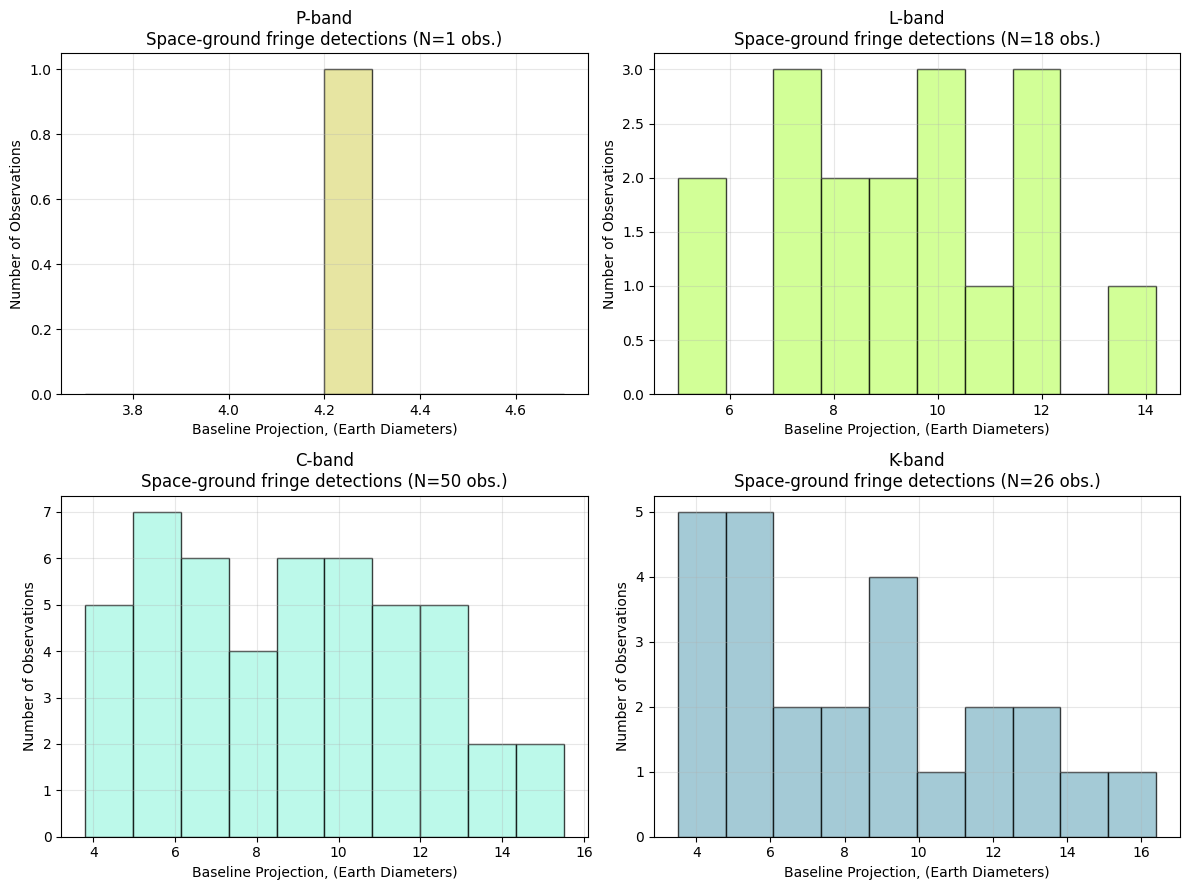

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, band in zip(axes, bands):
    data = df[df[band] == 1]
    if len(data) > 0:
        color = band_colors.get(band, 'steelblue')
        ax.hist(data['BL'], bins=10, alpha=0.75, color=color, edgecolor='black')
        ax.set_title(f'{band}-band\nSpace-ground fringe detections (N={len(data)} obs.)')
        ax.set_xlabel('Baseline Projection, (Earth Diameters)')
        ax.set_ylabel('Number of Observations')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data.', ha='center', va='center')

plt.tight_layout()
plt.show()

### Descriptive Statistics per Frequency Band

In [25]:
results = []

for band in bands:
    if band not in df.columns:
        continue
    total = len(df)
    valid = df[band].notna().sum()
    n0 = (df[band] == 0).sum()
    n1 = (df[band] == 1).sum()
    n2 = (df[band] == 2).sum()
    nx = (df[band].isna() | (df[band].astype(str).str.contains('x', case=False))).sum()
    
    success_rate = n1 / valid * 100 if valid > 0 else 0
    
    results.append({
        'Band': band,
        'Observed': valid,
        '0 (no correlation)': n0,
        '1 (space-ground)': n1,
        '2 (ground only)': n2,
        'x (not observed)': nx,
        'Fringe Detection Rate (%)': round(success_rate, 1)
    })

stats_df = pd.DataFrame(results)
print("Correlation statistics per band:")
print(f"Total observations: {total}")
print(stats_df.round(1).to_string(index=False))

Correlation statistics per band:
Total observations: 94
Band  Observed  0 (no correlation)  1 (space-ground)  2 (ground only)  x (not observed)  Fringe Detection Rate (%)
   P         3                   1                 1                1                91                       33.3
   L        36                  11                18                7                58                       50.0
   C        76                   6                50               20                18                       65.8
   K        56                   8                26               22                38                       46.4


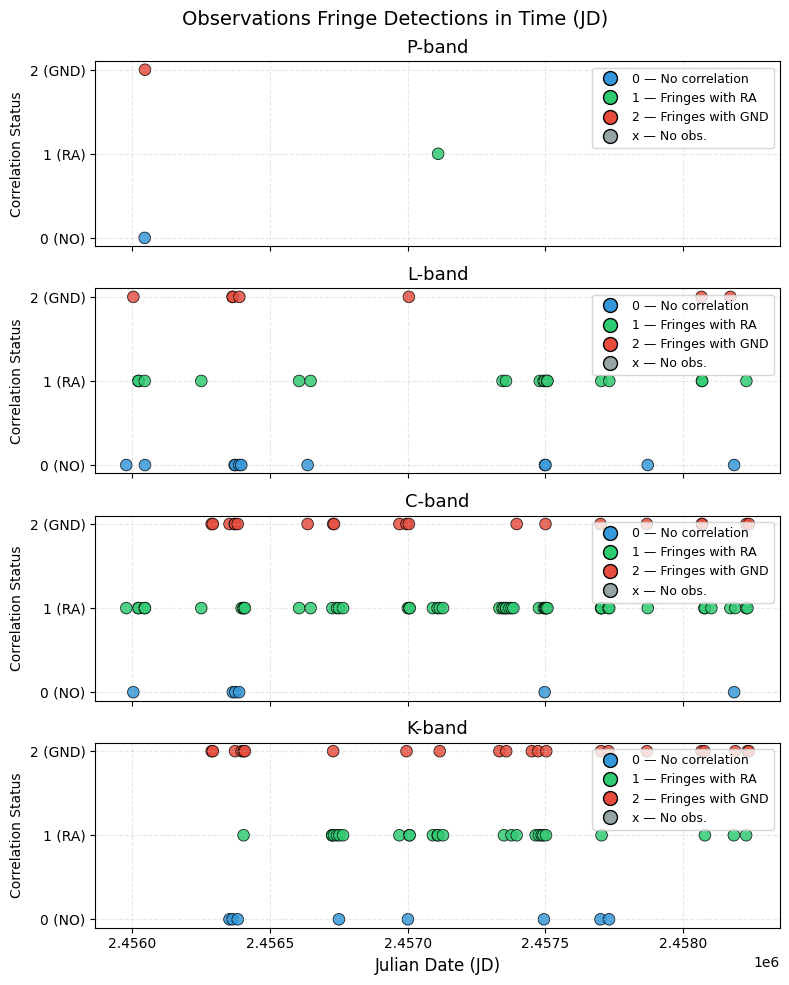

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

for ax, band in zip(axes, bands):
    data = df.copy()
    data['Status'] = pd.to_numeric(data[band], errors='coerce')
    
    colors = data['Status'].map(color_map)
    
    scatter = ax.scatter(data['Start_JD'], 
                        data['Status'], 
                        c=colors, 
                        s=70, 
                        alpha=0.85, 
                        edgecolors='black', 
                        linewidth=0.6)
    
    ax.set_title(f'{band}-band', fontsize=13)
    ax.set_ylabel('Correlation Status')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['0 (NO)', '1 (RA)', '2 (GND)'])
    
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='0 — No correlation',
                   markerfacecolor=color_map[0], markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', color='w', label='1 — Fringes with RA',
                   markerfacecolor=color_map[1], markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', color='w', label='2 — Fringes with GND',
                   markerfacecolor=color_map[2], markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', color='w', label='x — No obs.',
                   markerfacecolor=color_map[np.nan], markersize=10, markeredgecolor='black')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.xlabel('Julian Date (JD)', fontsize=12)
plt.suptitle('Observations Fringe Detections in Time (JD)', 
             fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

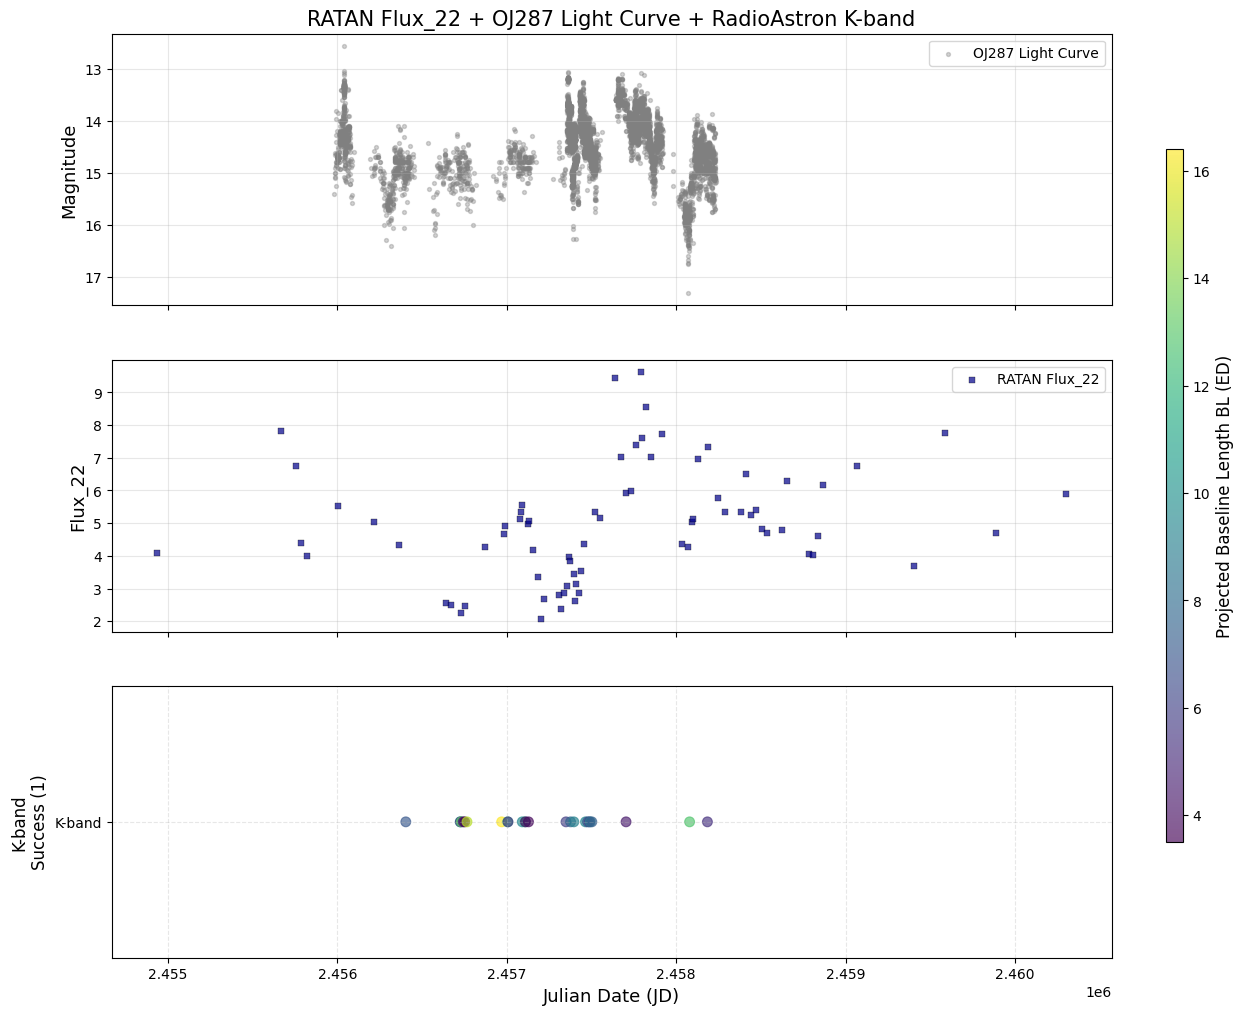

In [27]:
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1]})

ax0.scatter(flux['JD'], flux['Magnitude'], 
            s=8, alpha=0.35, color='gray', 
            label='OJ287 Light Curve', zorder=1)

ax0.set_ylabel('Magnitude', fontsize=13)
ax0.invert_yaxis()
ax0.grid(True, alpha=0.3)
ax0.set_title('RATAN Flux_22 + OJ287 Light Curve + RadioAstron K-band', fontsize=15)
ax0.legend(loc='upper right')

ax1.scatter(ratan['JD'], ratan['Flux_22'], 
            s=15, alpha=0.7, color='darkblue', 
            marker='s', edgecolors='black', linewidth=0.3,
            label='RATAN Flux_22', zorder=2)
ax1.set_ylabel('Flux_22', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

k_success = df[df['K'] == 1].copy()

if len(k_success) > 0:
    k_success['BL'] = pd.to_numeric(k_success['BL, (ED)'], errors='coerce')
    
    scatter = ax2.scatter(k_success['Start_JD'], 
                          [1.0] * len(k_success),
                          c=k_success['BL'], 
                          s=50, 
                          cmap='viridis',
                          alpha=0.65, 
                          linewidth=0.8,
                          marker='o')
    
    cbar = fig.colorbar(scatter, ax=[ax0, ax1, ax2], pad=0.02, aspect=40, shrink=0.75)
    cbar.set_label('Projected Baseline Length BL (ED)', fontsize=12)
    
    ax2.set_ylabel('K-band\nSuccess (1)', fontsize=12)
    ax2.set_yticks([1.0])
    ax2.set_yticklabels(['K-band'])

else:
    ax2.text(0.5, 0.5, "Нет успешных наблюдений в K-band", 
             ha='center', va='center', transform=ax2.transAxes, fontsize=14)

ax2.grid(True, alpha=0.3, linestyle='--')

plt.xlabel('Julian Date (JD)', fontsize=13)
ax2.tick_params(axis='x', labelbottom=True)

plt.subplots_adjust(right=0.75)
plt.show()

Number of points: 24


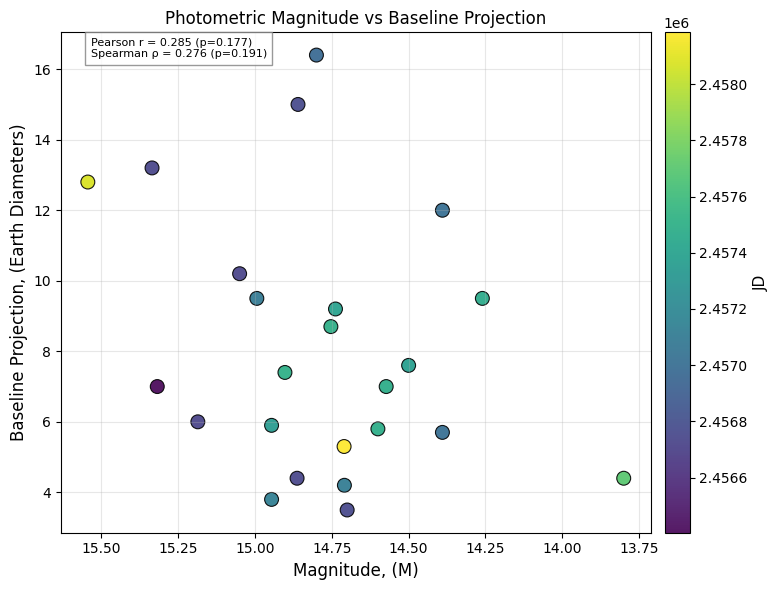

In [40]:
k_success = df[df['K'] == 1].copy()
k_success['BL'] = pd.to_numeric(k_success['BL, (ED)'], errors='coerce')

def find_nearest_mag(jd):
    if len(flux) == 0:
        return np.nan
    idx = (np.abs(flux['JD'] - jd)).argmin()
    return flux['Magnitude'].iloc[idx]

k_success['Magnitude'] = k_success['Start_JD'].apply(find_nearest_mag)

plot_data = k_success.dropna(subset=['Magnitude', 'BL'])

print(f"Number of points: {len(plot_data)}")

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(plot_data['Magnitude'], 
                     plot_data['BL'],
                     c=plot_data['Start_JD'],
                     s=100,
                     cmap='viridis',
                     alpha=0.9,
                     edgecolors='black',
                     linewidth=0.8)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('JD', fontsize=11)

ax.set_xlabel('Magnitude, (M)', fontsize=12)
ax.set_ylabel('Baseline Projection, (Earth Diameters)', fontsize=12)
ax.set_title('Photometric Magnitude vs Baseline Projection', fontsize=12)

ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Статистика
if len(plot_data) > 3:
    corr_p, p_p = pearsonr(plot_data['Magnitude'], plot_data['BL'])
    corr_s, p_s = spearmanr(plot_data['Magnitude'], plot_data['BL'])
    
    stats_text = f'Pearson r = {corr_p:.3f} (p={p_p:.3f})\nSpearman ρ = {corr_s:.3f} (p={p_s:.3f})'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

Numbe of points: 25


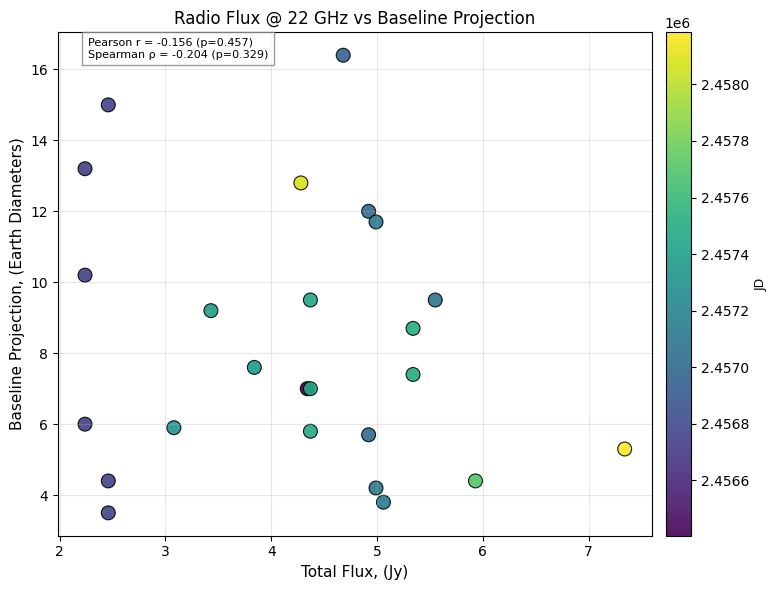

In [38]:
from scipy.stats import pearsonr, spearmanr

k_success = df[df['K'] == 1].copy()
k_success['BL'] = pd.to_numeric(k_success['BL, (ED)'], errors='coerce')

def find_nearest_flux(jd):
    if len(ratan) == 0:
        return np.nan
    idx = (np.abs(ratan['JD'] - jd)).argmin()
    return ratan['Flux_22'].iloc[idx]

k_success['Flux_22'] = k_success['Start_JD'].apply(find_nearest_flux)
plot_data = k_success.dropna(subset=['Flux_22', 'BL'])

print(f"Numbe of points: {len(plot_data)}")

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(plot_data['Flux_22'], 
                     plot_data['BL'],
                     c=plot_data['Start_JD'],
                     s=100,
                     cmap='viridis',
                     alpha=0.9,
                     edgecolors='black',
                     linewidth=0.8)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('JD', fontsize=9)

ax.set_xlabel('Total Flux, (Jy)', fontsize=11)
ax.set_ylabel('Baseline Projection, (Earth Diameters)', fontsize=11)
ax.set_title('Radio Flux @ 22 GHz vs Baseline Projection', fontsize=12)

ax.grid(True, alpha=0.3)
if len(plot_data) > 3:
    corr_p, p_p = pearsonr(plot_data['Flux_22'], plot_data['BL'])
    corr_s, p_s = spearmanr(plot_data['Flux_22'], plot_data['BL'])
    
    stats_text = f'Pearson r = {corr_p:.3f} (p={p_p:.3f})\nSpearman ρ = {corr_s:.3f} (p={p_s:.3f})'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()